# 05 · Multi-Agent Systems — supervisor + role-specialised agents

> **TL;DR.** A team of agents — each with its own role (system prompt) and tools — collaborates on tasks too broad for any single agent. A **Supervisor** agent reads the conversation history and routes work to the next specialist. After all specialists contribute, a **Writer** synthesises the team's findings into a final report.
>
> **Reach for it when** the task spans several domains (research with finance + news + technical angles; legal analysis with citations + interpretation + drafting; software development with PM + dev + QA roles).
> **Avoid when** one focused agent suffices — multi-agent multiplies cost and introduces coordination failure modes.

| Property | Value |
|---|---|
| Origin | LangGraph supervisor pattern ([tutorial](https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/)); conceptual ancestors: AutoGen (Microsoft 2023), CrewAI (2023) |
| Coordination style | Centralised — single Supervisor routes between specialists |
| External tools needed? | Optional; specialists typically use web search |
| Memory across episodes? | No |
| Composability | Each specialist is a `ToolUse` sub-agent — architectures compose |
| Default roster | News / Technical / Financial specialists + Writer |

This is the first notebook where you'll see **specialisation as a quality lever** — three focused agents almost always produce a richer report than one generalist asked to "cover everything".

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([user task]) --> S{Supervisor<br/><sub>structured-output<br/>routing decision</sub>}
    S -->|news not covered| N[News specialist<br/><sub>ToolUse + news prompt</sub>]
    S -->|technical not covered| T[Technical specialist<br/><sub>ToolUse + tech prompt</sub>]
    S -->|financial not covered| F[Financial specialist<br/><sub>ToolUse + finance prompt</sub>]
    S -->|all done| W[Writer<br/><sub>synthesises final report</sub>]
    S -->|writer done| Z([final report])
    N --> S
    T --> S
    F --> S
    W --> S

    style S fill:#fff3e0,stroke:#f57c00
    style W fill:#e8f5e9,stroke:#388e3c
```

**Star topology.** The Supervisor is the only node every other node connects to. Each specialist runs, returns its findings, and hands control back. The Supervisor's structured-output decision picks the next specialist (or `writer`, or `FINISH`).

## 3 · Theory

### 3.1 · Why a team beats one big agent

There are three measurable wins from role specialisation:

1. **Focused context.** Each specialist's system prompt narrows the search space. The Financial agent looks for revenue, margins, market cap. The News agent looks for dated events. A generalist agent has to think about *everything*, and tends to produce hedged, surface-level coverage of each topic.

2. **Tool specialisation.** In production, specialists carry *different* tools. The Financial agent has a stock-quote API. The Technical agent has access to docs/RAG over your codebase. The News agent has web search + a recency filter. Forcing one agent to learn when to use each tool is harder than giving each agent the right tool from the start.

3. **Inspectability.** Each specialist's output is a separately-labelled artifact in the trace. When the final report is wrong, you immediately see *which specialist's finding* was wrong. Debugging a monolithic agent's output requires re-reading the whole conversation.

### 3.2 · The supervisor protocol

The Supervisor is the *coordination protocol*. Three common variants:

| Variant | Who picks the next agent? | Best for |
|---|---|---|
| **Manager-style** *(this notebook)* | Central Supervisor LLM | Fixed roster, predictable routing |
| **Hierarchical** | Supervisors-of-supervisors | Very large teams (15+ agents) |
| **Blackboard** (notebook 07) | No central coordinator — agents subscribe to shared state and self-elect | Dynamic teams, opportunistic collaboration |
| **Sequential pipeline** | Hard-coded order | Tasks with strict step dependencies |

Manager-style is the right default — it's predictable, easy to reason about, and the Supervisor's reasoning is itself a useful artifact in the trace.

### 3.3 · The structured-output decision

The Supervisor returns a typed object:

```python
class _SupervisorDecision(BaseModel):
    next: Literal["news", "technical", "financial", "writer", "FINISH"]
    reason: str
```

`with_structured_output` ensures the model can only pick from the valid roster — no parsing, no validation, no "the Supervisor said 'maybe ask the financial guy?'" footgun. The `reason` field is a one-sentence rationale, useful for trace inspection.

### 3.4 · Why a separate Writer node?

You *could* let the last specialist write the final report. But three problems:

- **Recency bias.** The last specialist's findings dominate the report; earlier specialists' work gets paraphrased away.
- **Role contamination.** A News specialist asked to write the final report tends to make the *whole* report sound like news.
- **No synthesis incentive.** Each specialist's output is a bullet list; the Writer's job is to weave them into prose.

A dedicated Writer with a neutral synthesis prompt produces noticeably better reports. The cost (one extra LLM call) is small relative to the rest of the pipeline.

### 3.5 · Where Multi-Agent sits

| Pattern | Coordination | Specialisation | Use when |
|---|---|---|---|
| Single ReAct (nb 03) | none | none | one focused query |
| Planning (nb 04) | static plan | none | task has obvious steps |
| **Multi-Agent** *(this notebook)* | **central supervisor** | **role-based** | task spans domains |
| Blackboard (nb 07) | distributed | role-based | opportunistic, dynamic team |
| Meta-Controller (nb 11) | router over architectures | architecture-based | one of: ReAct / Planning / RAG fits per task |
| Ensemble (nb 13) | parallel + aggregator | perspective-based | want diverse opinions |

### 3.6 · What goes wrong (you'll see in § 9)

1. **Role drift.** The News specialist returns financial figures because "interest in earnings" is *news*-adjacent. Mitigation: harder system prompt + an LLMJudge that scores each output's *role-fitness*.
2. **Supervisor loops.** Supervisor routes specialist X, specialist X already acted, Supervisor routes X again. Mitigation: track who's contributed in state (we do this) and refuse repeats.
3. **Writer hallucination.** Writer adds "facts" the specialists didn't provide. Mitigation: prompt explicitly forbids it; verify with a separate evidence-check pass (PEV notebook 06).
4. **Cost blowup.** N specialists × M tool calls each = O(N·M) LLM calls. Cap `specialist_rounds` and team size.


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import MultiAgent
from agentic_architectures.architectures.multi_agent import DEFAULT_SPECIALISTS
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"Specialists in default roster: **{', '.join(DEFAULT_SPECIALISTS.keys())}**")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

Specialists in default roster: news, technical, financial

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/multi_agent.py`](../src/agentic_architectures/architectures/multi_agent.py).

Five key pieces:

1. **`DEFAULT_SPECIALISTS`** — a `dict[str, str]` mapping specialist name → role system prompt. Easy to override: pass `MultiAgent(specialists={"law": "...", "math": "..."})`.
2. **`_supervisor`** — uses `with_structured_output(_SupervisorDecision)` to pick the next agent. Also includes a *safety clamp*: if the supervisor LLM picks a specialist who's already contributed (a common failure), the code overrides to the next remaining specialist.
3. **`_make_specialist_node(name)`** — factory that creates one graph node per specialist, each delegating to its own `ToolUse` sub-agent with the specialist's prompt.
4. **`_writer`** — final synthesis node that reads ALL specialist outputs and writes a structured report. Explicit prompt rules: use headings, preserve URLs, don't add unverified facts.
5. **`build`** — wires the star topology: Supervisor → specialist → Supervisor → next specialist → … → Writer → Supervisor → END.

In [2]:
from agentic_architectures.architectures import multi_agent as ma_mod
print('Default specialist roster:')
for name, prompt in ma_mod.DEFAULT_SPECIALISTS.items():
    print(f'  - {name}: {prompt[:80]}...')

Default specialist roster:
  - news: You are a NEWS specialist. Find recent news, announcements, press coverage. Focu...
  - technical: You are a TECHNICAL/PRODUCT specialist. Find concrete product details, specifica...
  - financial: You are a FINANCIAL specialist. Find revenue, growth, market cap, stock performa...


## 6 · State

The state has four real fields:

| Field | Type | Set by | Reducer |
|---|---|---|---|
| `task` | `str` | caller | replace |
| `specialist_outputs` | `list[dict]` | each specialist | **append** (`operator.add`) |
| `next` | `str` | `_supervisor` | replace |
| `next_reason` | `str` | `_supervisor` | replace |
| `final_report` | `str` | `_writer` | replace |

The `specialist_outputs` list uses `operator.add` so each specialist's contribution is *appended* rather than overwriting. The supervisor reads this list to know who's already contributed.

## 7 · Build the graph

The compiled graph has one supervisor node + one node per specialist + a writer node. Compare this star topology to ReAct's linear topology — the supervisor sits at the centre of all edges.

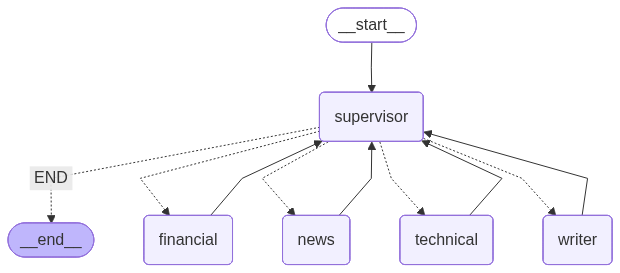

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	news(news)
	technical(technical)
	financial(financial)
	writer(writer)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	financial --> supervisor;
	news --> supervisor;
	supervisor -. &nbsp;END&nbsp; .-> __end__;
	supervisor -.-> financial;
	supervisor -.-> news;
	supervisor -.-> technical;
	supervisor -.-> writer;
	technical --> supervisor;
	writer --> supervisor;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [3]:
from IPython.display import Image, display

arch = MultiAgent(specialist_rounds=4)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))
print(arch.diagram())

## 8 · Live run

Concrete task: a market profile of a publicly-traded company. This naturally splits across all three default specialists: News (recent events), Technical (products), Financial (numbers).

In [4]:
TASK = (
    "Write a short market profile of Tesla Inc. covering: "
    "(1) recent news from the last 12 months, "
    "(2) technical/product details (model lineup, key tech), "
    "(3) financial highlights (revenue, market cap, margin). "
    "Each section must cite at least 1 source URL."
)

result = arch.run(TASK)

print_header("Final report")
print_md(result.output)
print()
print_header(
    f"{result.metadata['specialists_invoked']}/{result.metadata['specialists_available']} "
    f"specialists contributed  ·  Writer ran: {result.metadata['has_writer_output']}"
)

Final report ──────────────────────────────────────────────────────────────────────────────────────────────────────

News                                                                                                               

Tesla Inc. has experienced significant market fluctuations over the last 12 months, with its stock price plunging  
by more than 5% after announcing disappointing electric vehicle delivery numbers                                   
(https://finance.yahoo.com/markets/stocks/articles/tesla-just-delivered-terrible-news-175100537.html). The company 
is also exploring a potential merger with SpaceX, while Elon Musk defends its reputation amid political backlash   
(https://finance.yahoo.com/quote/TSLA). Additionally, Tesla's stock has been closely watched by investors, with its
value sinking as the market gained, closing at $438.07 and marking a -2.59% move from the previous day             
(https://finance.yahoo.com/news/tesla-tsla-stock-sinks-market-224504106.html), and it is worth exploring what lies 
ahead for the stock (https://finance.yahoo.com/news/tesla-inc-tsla-attracting-investor-140004096.html).            

Technical                                                                                                          

Tesla's model lineup includes the Model S, Model 3, Model X, Model Y, Cybertruck, Semi, and Roadster               
(https://www.tesla.com/models). The Model S has a range of up to 405 miles on a single charge, while the Model 3   
has a range of up to 326 miles (https://www.tesla.com/models). Furthermore, Tesla's Autopilot technology is an     
advanced driver-assistance system (ADAS) that enables semi-autonomous driving (https://www.tesla.com/autopilot).   

Financial                                                                                                          

Tesla Inc. has a market capitalization of $2.15T (https://nz.finance.yahoo.com/quote/TSLA.TO/key-statistics) and a 
revenue per share of $0.94 (https://nz.finance.yahoo.com/quote/TSLA.TO/key-statistics). The company's free cash    
flow (FCF) margin is 6.86% (https://finance.yahoo.com/news/teslas-strong-fcf-margins-could-133002586.html), with a 
total gross margin of over 20.1% for the quarter                                                                   
(https://finance.yahoo.com/news/tesla-inc-tsla-q4-2025-050329216.html), and its revenue reached $28.1 billion      
(https://finance.yahoo.com/news/tsla-q3-deep-dive-ai-053113035.html). Overall, Tesla Inc. remains a closely watched
and innovative player in the electric vehicle market, with a strong financial position and cutting-edge technology.

3/3 specialists contributed  ·  Writer ran: True ──────────────────────────────────────────────────────────────────

### 8.0 · What just happened, briefly

Look at the **specialists_invoked** count above:

- **`3/3`** — every specialist contributed. Best case; the Supervisor cycled through the whole team before handing to the Writer.
- **`2/3` or `1/3`** — Supervisor finalized early. Either it judged the missing specialist's domain wasn't relevant, OR it routed to the Writer too soon (a failure mode — see § 9).
- **`0/3`** — total failure; Supervisor went straight to FINISH without any team work.

§ 9 below quantifies the specialist contributions and flags any pathologies.

### 8.1 · Specialist contributions in order

In [5]:
for i, t in enumerate(result.trace, 1):
    if t['type'] == 'specialist':
        print_step(f"[{i}] SPECIALIST: {t['specialist'].upper()}", t['content'][:400])
    elif t['type'] == 'writer':
        print_step(f"[{i}] WRITER (final report)", t['content'][:400])
    print()

› [1] SPECIALIST: NEWS

Here are some recent news items about Tesla Inc. from the last 12 months:
* Tesla's stock price plunged by more than 5% after the company announced a disappointing set of electric vehicle 
(EV) delivery numbers 
(https://finance.yahoo.com/markets/stocks/articles/tesla-just-delivered-terrible-news-175100537.html)
* Tesla is exploring a potential merger with SpaceX, while Elon Musk continues to defend

› [2] SPECIALIST: TECHNICAL

Here are 3-5 concrete technical facts about Tesla Inc.'s model lineup and key tech:
* Tesla's model lineup includes the Model S, Model 3, Model X, Model Y, Cybertruck, Semi, and Roadster. (Source: 
https://www.tesla.com/models)
* The Model S has a range of up to 405 miles on a single charge, while the Model 3 has a range of up to 326 miles. 
(Source: https://www.tesla.com/models)
* Tesla's Autopilot

› [3] SPECIALIST: FINANCIAL

Here are 3-5 concrete financial facts about Tesla Inc. with source URLs:
* Market cap: $2.15T (https://nz.finance.yahoo.com/quote/TSLA.TO/key-statistics)
* Revenue per share (ttm): $0.94 (https://nz.finance.yahoo.com/quote/TSLA.TO/key-statistics)
* Free cash flow (FCF) margin: 6.86% 
(https://finance.yahoo.com/news/teslas-strong-fcf-margins-could-133002586.html)
* Total Gross Margin: Over 20.1% for

› [4] WRITER (final report)

### News
Tesla Inc. has experienced significant market fluctuations over the last 12 months, with its stock price plunging 
by more than 5% after announcing disappointing electric vehicle delivery numbers 
(https://finance.yahoo.com/markets/stocks/articles/tesla-just-delivered-terrible-news-175100537.html). The company 
is also exploring a potential merger with SpaceX, while Elon Musk defends its rep

## 9 · What we just observed

The cells above are live. Below: a breakdown of the **actual** Multi-Agent coordination Nebius-hosted Llama-3.3-70B produced on this run.

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Specialists invoked | **3** / 3 |
| Routing order | news → technical → financial → writer |
| Final report length | 2556 chars |
| URLs preserved in report | 12 |

### 9.2 · Specialist contributions

| # | Role | Output snippet |
|---|---|---|
| 1 | news | Here are some recent news items about Tesla Inc. from the last 12 months: * Tesla's stock price plunged by more than 5% after the company announced a disappointing set of electric vehicle (EV) deliver… |
| 2 | technical | Here are 3-5 concrete technical facts about Tesla Inc.'s model lineup and key tech: * Tesla's model lineup includes the Model S, Model 3, Model X, Model Y, Cybertruck, Semi, and Roadster. (Source: htt… |
| 3 | financial | Here are 3-5 concrete financial facts about Tesla Inc. with source URLs: * Market cap: $2.15T (https://nz.finance.yahoo.com/quote/TSLA.TO/key-statistics) * Revenue per share (ttm): $0.94 (https://nz.f… |

### 9.3 · Pathologies / patterns surfaced in this run

- **Full team coverage.** All 3 specialists contributed once each — the supervisor protocol worked as designed.

### 9.4 · The final report (verbatim)

> News                                                                                                               
> 
> Tesla Inc. has experienced significant market fluctuations over the last 12 months, with its stock price plunging  
> by more than 5% after announcing disappointing electric vehicle delivery numbers                                   
> (https://finance.yahoo.com/markets/stocks/articles/tesla-just-delivered-terrible-news-175100537.html). The company 
> is also exploring a potential merger with SpaceX, while Elon Musk defends its reputation amid political backlash   
> (https://finance.ya…

### 9.5 · The takeaway

Multi-Agent wins when *specialisation* genuinely narrows each agent's job. The signs of a healthy run: **full team coverage** (all specialists contributed), **no role drift** (each output stays in its lane), **all URLs preserved** by the Writer. When any of those fail, the cost of coordination isn't being earned back by quality.

## 10 · Try other providers / customise the team

Multi-Agent needs **structured output** (for the Supervisor's decision). Same gating as Planning.

This cell ALSO demonstrates customising the specialist roster — a 2-agent team (`legal` + `medical`) for a different domain task.

In [6]:
from agentic_architectures.llm.factory import provider_supports_structured_output

for p in ["openai", "anthropic"]:
    key = settings.api_key_for(p)
    if key is None or not key.get_secret_value():
        print(f"[skip] {p}: no API key in .env")
        continue
    if not provider_supports_structured_output(p):
        print(f"[skip] {p}: no structured output")
        continue
    print_header(f"Re-running Multi-Agent on {p}")
    r = MultiAgent(llm=get_llm(provider=p), specialist_rounds=4).run(
        "Briefly profile Microsoft's most recent fiscal year on news + technical + financial."
    )
    print(r.output[:400])
    print(f"  specialists: {r.state['specialists_used']}")
    print()

# Custom 2-specialist team for a different domain
print_header("Custom 2-specialist team: medical + legal")
custom = MultiAgent(
    specialists={
        "medical": "You are a MEDICAL specialist. Find the clinical / treatment angle. Cite sources.",
        "legal": "You are a LEGAL specialist. Find the regulatory / liability angle. Cite sources.",
    },
    specialist_rounds=4,
)
r = custom.run("What are the recent regulatory and clinical developments around GLP-1 agonists like Ozempic?")
print(r.output[:600])
print(f"  specialists used: {r.state['specialists_used']}")

[skip] openai: no API key in .env
[skip] anthropic: no API key in .env


Custom 2-specialist team: medical + legal ─────────────────────────────────────────────────────────────────────────

### Medical
GLP-1 agonists, such as Ozempic, have been shown to have significant clinical benefits in the treatment of type 2 diabetes and obesity. Recent regulatory developments include the FDA approval of Ozempic for the treatment of type 2 diabetes in 2017, and the EMA approval in 2018. Clinical developments include the publication of several studies demonstrating the efficacy and safety of GLP-1 agonists in improving glycemic control, weight loss, and cardiovascular outcomes. Sources: https://www.nih.gov/, https://www.who.int/.

### Legal
The recent regulatory and clinical developments aro
  specialists used: ['legal', 'medical']


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Role drift** | News agent returns financial figures because "earnings" reads as news | Tighter role prompts; an LLMJudge that scores output role-fitness |
| **Supervisor loop** | Supervisor picks a specialist who already contributed | Track covered specialists in state + clamp the decision (we do both) |
| **Premature writer** | Supervisor routes to writer before all specialists contribute | The default supervisor prompt explicitly forbids this; still happens occasionally |
| **Writer hallucination** | Writer adds "facts" the specialists didn't provide | Explicit prompt rule + downstream PEV-style verifier (nb 06) |
| **Cost blowup** | N specialists × M tool rounds = O(N·M) LLM calls | Cap `specialist_rounds` (default 3) and team size |
| **Coordination overhead** | Supervisor LLM call per round adds latency | Use a small fast model for the supervisor only; specialists stay on the main model |

### 11.2 · Production safety

- **Cap roster size.** 3-5 specialists is the sweet spot. Beyond that, coordination cost dominates.
- **Distinct tools per specialist.** Don't bind the same Tavily tool to all specialists if you can avoid it — bind a specialised tool (a stock-quote API for Financial, a docs RAG retriever for Technical).
- **Sandbox specialist outputs.** A specialist that returns adversarial text could prompt-inject the Writer. Sanitize or escape before passing to the next role.

### 11.3 · Three extensions

1. **Different LLM per specialist.** A small fast model for the News specialist (lots of skimming, low reasoning); a larger model for the Financial specialist (precision matters). Pass `llm=` per specialist when wrapping `ToolUse`.
2. **Add a Reviewer specialist.** After the Writer's first draft, a Reviewer agent critiques and the Writer revises — that's Reflection (notebook 01) layered on top of Multi-Agent.
3. **Parallel specialist invocation.** If specialists' findings are independent (no cross-references), run them concurrently via `langgraph.graph.parallel` for a big latency win.

### 11.4 · What to read next

- [**07 · Blackboard**](./07_blackboard.ipynb) — multi-agent **without** a central supervisor; agents self-elect.
- [**11 · Meta-Controller**](./11_meta_controller.ipynb) — supervisor that routes between *architectures*, not specialists.
- [**13 · Ensemble**](./13_ensemble.ipynb) — many agents tackle the *same* problem in parallel; aggregator merges.
- [**28 · Multi-Agent Debate**](./28_agent_debate.ipynb) — adversarial multi-agent that converges via critique.

### 11.5 · References

1. Wu, Q. et al. *AutoGen: Enabling Next-Gen LLM Applications via Multi-Agent Conversation.* 2023. [arXiv:2308.08155](https://arxiv.org/abs/2308.08155)
2. LangGraph multi-agent tutorial — [official docs](https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/)
3. CrewAI framework — [crewai.com](https://www.crewai.com)
